In [8]:
import undetected_chromedriver as uc
from selenium.webdriver.common.by import By
from tqdm import tqdm
import time

def coupang_crawl(search, page):
    options = uc.ChromeOptions()
    options.add_argument("--start-maximized")

    driver = uc.Chrome(options=options, version_main=146)

    href_list = []

    # 1페이지부터 page페이지까지 href 수집
    for p in range(1, page + 1):
        driver.get(f"https://www.coupang.com/np/search?component=&q={search}&traceId=mmll3jcw&channel=user&page={p}")
        time.sleep(2)

        link = driver.find_elements(By.CSS_SELECTOR, 'li.ProductUnit_productUnit__Qd6sv>a')
        for i in range(len(link)):
            href = link[i].get_attribute('href')
            if href not in href_list:
                href_list.append(href)

    f = open(f'./data/쿠팡_{search}.txt', 'w', encoding='utf-8')

    # 컬럼명
    f.write("name|price\n")

    for i in tqdm(range(len(href_list))):
        try:
            driver.get(href_list[i])
            time.sleep(2)

            # 상품명
            name = driver.find_element(
                By.CSS_SELECTOR,
                'div.twc-flex.twc-justify-between.twc-items-start > div > h1'
            ).text

            # 가격
            price = driver.find_element(
                By.CSS_SELECTOR,
                'div.final-price.twc-flex.twc-items-center.twc-flex-wrap > div'
            ).text

            # 파일 저장
            f.write(f"{name}|{price}\n")

        except:
            continue

    f.close()
    driver.quit()

    return '추출 완료'

In [9]:
coupang_crawl("분유포트", 10)

InvalidSessionIdException: Message: invalid session id: session deleted as the browser has closed the connection
from disconnected: not connected to DevTools
  (Session info: chrome=145.0.7632.160); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#invalidsessionidexception
Stacktrace:
Symbols not available. Dumping unresolved backtrace:
	0x977dd3
	0x977e14
	0x781db0
	0x770d4e
	0x78f895
	0x7f52ec
	0x80b0d9
	0x7ee7d6
	0x7c0049
	0x7c0e04
	0xbd6924
	0xbd1bf7
	0xbef5a0
	0x990f58
	0x99891d
	0x980648
	0x980812
	0x96a21a
	0x74b65d49
	0x76f6d81b
	0x76f6d7a1


In [3]:
import pandas as pd
df = pd.read_csv('./data/쿠팡_분유포트.txt', sep='|')
print(f"로딩 완료: {df.shape}")
df

로딩 완료: (248, 2)


,name,price
0,파파야나인 봄봄 출수형 주전자형 분유포트,"133,000원"
1,미가 분유포트 스마트 온도조절 전기포트 온수 보온 분유 조유기 수유용 온수기,"45,800원"
2,리웨이 허그 원터치 분유포트,"52,200원"
3,보르르 분유포트단일상품,"95,000원"
4,보아르 아가맘마 통유리 보온 퓨어 분유포트,"69,000원"
...,...,...
243,"하기스 2024 매직컴포트 팬티형 기저귀 남녀공용, 6단계, 144매","74,730원"
244,모리츠 스테인리스 전기 드립포트 1.2L,"29,800원"
245,과일모양 초콜릿 50개입 선택형,"10,200원"
246,"엄마의선택 구연산, 1kg, 2개","11,560원"


In [4]:
df = df[
    df['name'].str.contains('분유포트') &
    df['name'].str.contains('분유|포트')
]
df = df.reset_index(drop=True)
df

,name,price
0,파파야나인 봄봄 출수형 주전자형 분유포트,"133,000원"
1,미가 분유포트 스마트 온도조절 전기포트 온수 보온 분유 조유기 수유용 온수기,"45,800원"
2,리웨이 허그 원터치 분유포트,"52,200원"
3,보르르 분유포트단일상품,"95,000원"
4,보아르 아가맘마 통유리 보온 퓨어 분유포트,"69,000원"
...,...,...
84,보아르 아가온 분유포트 대용량 보온 원터치 출수 분리형 물통 3L,"127,000원"
85,보아르 이지 전기포트 M1 접이식 분유포트 휴대용 미니 여행용 온도조절 커피포트,"49,800원"
86,이즈홈 스마트 1.8L 티포트 약탕기 커피포트 분유포트 전기포트 전기주전자,"43,500원"
87,보아르 아가맘마 통유리 보온 퓨어 분유포트,"69,000원"


In [5]:
df.to_csv('./data/쿠팡_분유포트.csv', index=False, encoding='utf-8-sig')

In [6]:
df['price_num'] = df['price'].str.replace('원','').str.replace(',','').astype(int)

In [7]:
df.sort_values('price_num', ascending=True)

,name,price,price_num
72,"분유포트구연산 가열식가습기구연산 발포 구연산 가습기, 1개, 1L","13,300원",13300
11,대용량 디지털 전기포트 유리 커피포트 티포트 보온 분유포트 전기주전자 온도조절 1....,"24,900원",24900
41,"위마망 접이식 분유포트 접이식 전기포트, 1개, 샌드베이지[600ml]","29,000원",29000
40,"위마망 접이식 분유포트 접이식 전기포트, 1개, 화이트[600ml]","29,000원",29000
58,리빙센스 2021년형 티포트 1.8L LSK-1870 티메이커 분유포트 약탕기,"31,500원",31500
...,...,...,...
13,[라비킷 공식] 분유포트 통분리세척 4세대 전기포트 출산선물,"199,000원",199000
80,올인원 분리형 분유포트 UV 젖병 살균기 소독기,"280,500원",280500
9,닥터하르 2in1 분유포트 젖병 소독기 올인원 일체형 UV 살균기,"308,000원",308000
29,닥터하르 2in1 분유포트 젖병 소독기 올인원 일체형 UV 살균기,"308,000원",308000


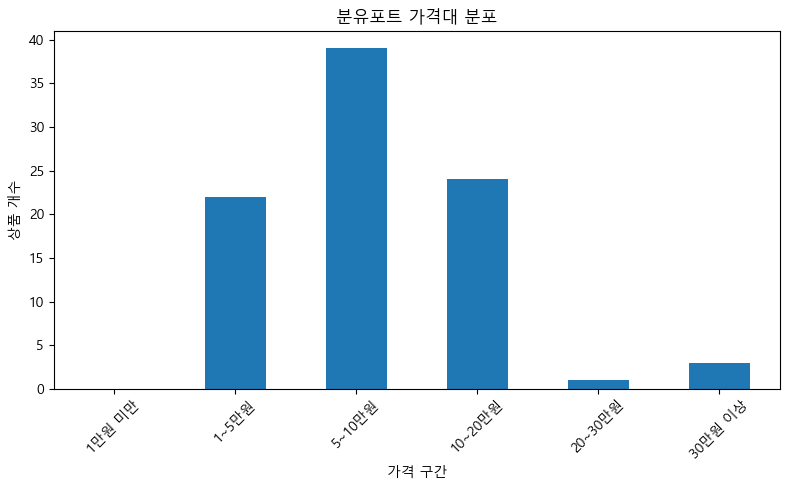

In [9]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 가격 구간 설정
bins = [0,10000,50000,100000,200000,300000,10000000]
labels = [
    '1만원 미만',
    '1~5만원',
    '5~10만원',
    '10~20만원',
    '20~30만원',
    '30만원 이상'
]

df['price_range'] = pd.cut(df['price_num'], bins=bins, labels=labels)

# 개수 집계
price_count = df['price_range'].value_counts().sort_index()

# 그래프
plt.figure(figsize=(8,5))
price_count.plot(kind='bar')

plt.title('분유포트 가격대 분포')
plt.xlabel('가격 구간')
plt.ylabel('상품 개수')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()